读取数据
AnnData: AnnData object with n_obs × n_vars = 1289 × 8772
    obs: 'index'
    var: 'index'
    uns: 'gt_key', 'milestone_network', 'milestone_percentages', 'start_id', 'timecourse'
细胞数: 1289, 基因数: 8772

obs columns:
['index']

obsm keys:
[]

obsp keys:
[]

前10个细胞ID:
['E3.1.443', 'E3.1.444', 'E3.1.445', 'E3.1.447', 'E3.1.448', 'E3.2.449', 'E3.2.450', 'E3.2.452', 'E3.2.453', 'E3.2.454']

预处理
HVG 后数据: AnnData object with n_obs × n_vars = 1289 × 900
    obs: 'index'
    var: 'index', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'gt_key', 'milestone_network', 'milestone_percentages', 'start_id', 'timecourse', 'log1p', 'hvg'

构建网络


  File "d:\anaconda\envs\DeepGFT\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\anaconda\envs\DeepGFT\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\anaconda\envs\DeepGFT\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\anaconda\envs\DeepGFT\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


gene edges 100742 spots 1289
已生成 cellnet_adj / spotnet_adj / genenet

计算 GFT 特征
adata_hvg.X type before fix: <class 'numpy.ndarray'>
adata_hvg.X type after fix: <class 'scipy.sparse._csr.csr_matrix'>

训练 DeepGFT
spot*signal train


100%|██████████| 200/200 [00:05<00:00, 37.47it/s]



从细胞ID提取真实阶段
stage_from_cellid 分布：
stage_from_cellid
Embryonic_day_7    411
Embryonic_day_6    345
Embryonic_day_5    304
Embryonic_day_4    154
Embryonic_day_3     75
Name: count, dtype: int64

cascat_clusters 分布：
cascat_clusters
Embryonic_day_7    411
Embryonic_day_6    345
Embryonic_day_5    304
Embryonic_day_4    154
Embryonic_day_3     75
Name: count, dtype: int64

UMAP 可视化

轨迹推断
轨迹参数：
{'root': 'Embryonic_day_3', 'a_k': 20, 'ncomp': 10, 'threshold': 0.15, 'job_dir': 'result\\trajectory\\real1_from_cellid', 'seed': 2023, 'data_name': 'real1_from_cellid'}
using keys are cascat_clusters, cascat_embedding, cascat_connectivities, cascat_pseudotime, cascat_di_matrix
group_frac:                  Embryonic_day_6  Embryonic_day_5  Embryonic_day_4  \
Embryonic_day_6            345.0              0.0              0.0   
Embryonic_day_5              0.0            304.0              0.0   
Embryonic_day_4              0.0              0.0            154.0   
Embryonic_day_7              0.0  

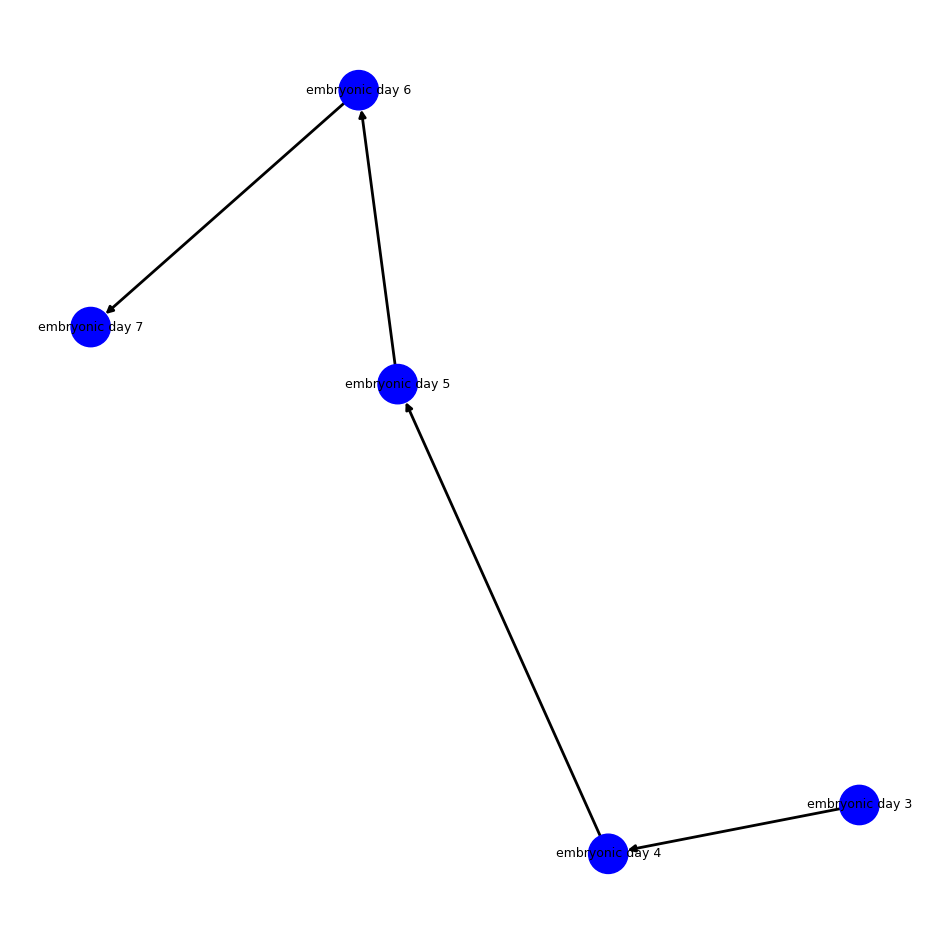

已保存 milestone_network.png
DIPlot 失败： No cluster label found in adata.obs

保存结果


TypeError: 0 of type <class 'int'> is an invalid key. Should be str.

Above error raised while writing key 'genenet' of <class 'h5py._hl.group.Group'> to /

In [ ]:
import os
import re
import shutil
import warnings
from pathlib import Path
import argparse

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import sklearn.neighbors
from scipy.sparse import csr_matrix
from scipy import sparse
from matplotlib import pyplot as plt

from DiverTI.utils import *
from DiverTI.genenet import obtain_genenet
from DiverTI.train import *

from infer import InferExperiment
from util.Plot import plot_gt_milestone_network
from models.model_utils import DIPlot

warnings.filterwarnings("ignore")
os.environ["R_HOME"] = r"D:\R-4.5.0"   
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
seed_all(2023)

DATA_PATH = r"F:\DiverTI\realdata\real1\data.h5ad"
ROOT_LABEL = "Embryonic_day_3"

OUTDIR = Path("./result/trajectory/real1_from_cellid")
if OUTDIR.exists():
    shutil.rmtree(OUTDIR)
OUTDIR.mkdir(parents=True, exist_ok=True)

def obtain_cellnet(adata, k_cutoff=6, use_pca=True, pca_dim=50, prune=True):
    if use_pca:
        if "X_pca" not in adata.obsm:
            sc.pp.pca(adata, n_comps=pca_dim)
        coords = adata.obsm["X_pca"]
    else:
        coords = adata.obsm.get("spatial", None)
        if coords is None:
            raise ValueError("No spatial coordinates and PCA not enabled, cannot build network.")

    nbrs = sklearn.neighbors.NearestNeighbors(
        n_neighbors=k_cutoff + 1,
        n_jobs=-1
    )
    nbrs.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    if prune:
        non_zero_mask = distances > 0
        non_zero_distances = np.where(non_zero_mask, distances, np.nan)
        means = np.nanmean(non_zero_distances, axis=1, keepdims=True)
        stds = np.nanstd(non_zero_distances, axis=1, keepdims=True)
        boundaries = means + stds
        mask = distances > boundaries
        distances[mask] = 0

    cell_indices = np.repeat(
        np.arange(len(coords)),
        np.fromiter((len(idx) for idx in indices), dtype=int)
    )
    neighbor_indices = np.concatenate(indices)
    neighbor_distances = np.concatenate(distances)

    cell_net_df = pd.DataFrame({
        "Cell1_idx": cell_indices,
        "Cell2_idx": neighbor_indices,
        "Distance": neighbor_distances
    })
    cell_net_df = cell_net_df[cell_net_df["Distance"] > 0].copy()

    cell_adj = csr_matrix(
        (
            (cell_net_df["Distance"].values > 0).astype(np.int8),
            (cell_net_df["Cell1_idx"], cell_net_df["Cell2_idx"])
        ),
        shape=(adata.n_obs, adata.n_obs)
    )

    adata.obsp["cellnet_adj"] = cell_adj

    id_cell_trans = dict(zip(range(len(coords)), adata.obs.index))
    cell_net_df["Cell1"] = cell_net_df["Cell1_idx"].map(id_cell_trans)
    cell_net_df["Cell2"] = cell_net_df["Cell2_idx"].map(id_cell_trans)
    adata.uns["cellnet"] = cell_net_df[["Cell1", "Cell2", "Distance"]]

    return adata
def extract_stage_from_cell_id(cell_id: str):
    s = str(cell_id).strip()
    m = re.match(r"^[Ee]([3-7])(?:[._\-]|$)", s)
    if m:
        return f"Embryonic_day_{m.group(1)}"
    return np.nan

print("=" * 80)
print("Reading data")
print("=" * 80)

adata = sc.read_h5ad(DATA_PATH)
print("AnnData:", adata)
print(f"Number of cells: {adata.n_obs}, Number of genes: {adata.n_vars}")

print("\nobs columns:")
print(adata.obs.columns.tolist())

print("\nobsm keys:")
print(list(adata.obsm.keys()))

print("\nobsp keys:")
print(list(adata.obsp.keys()))

print("\nFirst 10 cell IDs:")
print(adata.obs_names[:10].tolist())


print("\n" + "=" * 80)
print("=" * 80)

adata.var_names_make_unique()
prefilter_genes(adata, min_cells=3)

if "log1p" not in adata.uns:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=900,
    flavor="seurat",
    inplace=True
)

adata_hvg = adata[:, adata.var["highly_variable"]].copy()
print("Data after HVG:", adata_hvg)

adata_hvg.write_h5ad(OUTDIR / "adata_real1_hvg_processed.h5ad")

print("\n" + "=" * 80)
print("Building network")
print("=" * 80)

obtain_cellnet(adata_hvg, k_cutoff=6, use_pca=True, pca_dim=50, prune=True)
obtain_genenet(adata_hvg)

adata_hvg.uns["spotnet_adj"] = adata_hvg.obsp["cellnet_adj"].toarray()
adata_hvg.uns["spotnet"] = adata_hvg.uns["cellnet"]

print("Generated cellnet_adj / spotnet_adj / genenet")

print("\n" + "=" * 80)
print("Computing GFT features")
print("=" * 80)

print("adata_hvg.X type before fix:", type(adata_hvg.X))
if not sparse.issparse(adata_hvg.X):
    adata_hvg.X = sparse.csr_matrix(np.asarray(adata_hvg.X))
print("adata_hvg.X type after fix:", type(adata_hvg.X))

gene_freq_mtx, gene_eigvecs_T, gene_eigvals = f2s_gene(
    adata_hvg,
    gene_signal=1500,
    c1=0.05
)

spot_freq_mtx, spot_eigvecs_T, spot_eigvals = f2s_spot(
    adata_hvg,
    spot_signal=1500,
    middle=3,
    c2=0.005
)



print("\n" + "=" * 80)
print("Training DiverTI")
print("=" * 80)

res, lamda, emb_spot, _, attention = train_spot(
    adata_hvg,
    gene_freq_mtx,
    gene_eigvecs_T,
    spot_freq_mtx,
    spot_eigvecs_T,
    alpha=20,
    device=device,
    epoch_max=200,
    cluster=False
)

adata_hvg.obsm["emb"] = emb_spot
adata_hvg.obsm["cascat_embedding"] = adata_hvg.obsm["emb"].copy()

sc.pp.neighbors(adata_hvg, use_rep="emb")
sc.tl.umap(adata_hvg)

sc.pl.umap(adata_hvg, color=None, show=False)
plt.savefig(OUTDIR / "umap_embedding.png", dpi=300, bbox_inches="tight")
plt.close()


print("\n" + "=" * 80)
print("=" * 80)

adata_hvg.obs["stage_from_cellid"] = [
    extract_stage_from_cell_id(x) for x in adata_hvg.obs_names
]

print("stage_from_cellid 分布：")
print(adata_hvg.obs["stage_from_cellid"].value_counts(dropna=False))

if adata_hvg.obs["stage_from_cellid"].isna().any():
    bad_ids = adata_hvg.obs_names[adata_hvg.obs["stage_from_cellid"].isna()].tolist()[:30]
    raise ValueError(
        "Some cell names could not be resolved to E3~E7, please check these cell_id:\n" +
        "\n".join(map(str, bad_ids))
    )

adata_hvg.obs["cascat_clusters"] = adata_hvg.obs["stage_from_cellid"].astype(str)

print("\ncascat_clusters distribution:")
print(adata_hvg.obs["cascat_clusters"].value_counts())

if ROOT_LABEL not in set(adata_hvg.obs["cascat_clusters"].unique()):
    raise ValueError(f"{ROOT_LABEL} not found in cascat_clusters")


print("\n" + "=" * 80)
print("UMAP visualization")
print("=" * 80)

sc.pl.umap(
    adata_hvg,
    color=["cascat_clusters"],
    title=["Stage from Cell ID"],
    show=False
)
plt.savefig(OUTDIR / "umap_stage_from_cellid.png", dpi=300, bbox_inches="tight")
plt.close()

print("\n" + "=" * 80)
print("Trajectory inference")
print("=" * 80)

parser = argparse.ArgumentParser()
parser.add_argument("--root", type=str, default=ROOT_LABEL)
parser.add_argument("--a_k", type=int, default=20)          
parser.add_argument("--ncomp", type=int, default=10)
parser.add_argument("--threshold", type=float, default=0.15) 
parser.add_argument("--job_dir", type=str, default=str(OUTDIR))
parser.add_argument("--seed", type=int, default=2023)
parser.add_argument("--data_name", type=str, default="real1_from_cellid")
args_traj = parser.parse_args([])

print("Trajectory parameters:")
print(vars(args_traj))

exp = InferExperiment(args_traj, adata=adata_hvg)
exp.infer()

print("\nTrajectory inference completed")
if "root" in adata_hvg.uns:
    print("root:", adata_hvg.uns["root"])
if "start_id" in adata_hvg.uns:
    print("start_id:", adata_hvg.uns["start_id"])

print("\n" + "=" * 80)
print("Checking directed tree adjacency matrix")
print("=" * 80)

if "cascat_directed_tree_conn" in adata_hvg.uns:
    tree_conn = adata_hvg.uns["cascat_directed_tree_conn"]
    print(tree_conn)

    print("\nOut-degree of each node:")
    print(tree_conn.sum(axis=1))

    print("\nIn-degree of each node:")
    print(tree_conn.sum(axis=0))
else:
    print("adata_hvg.uns['cascat_directed_tree_conn'] not found.")


print("\n" + "=" * 80)
print("Checking milestone results")
print("=" * 80)

if "milestone_percentages" in adata_hvg.uns:
    milestone_long = adata_hvg.uns["milestone_percentages"]

    print("First 5 rows of milestone_percentages:")
    try:
        print(milestone_long.head())
    except Exception:
        print(type(milestone_long))

    try:
        milestone_wide = milestone_long.pivot(
            index="cell_id",
            columns="milestone_id",
            values="percentage"
        )
        milestone_wide = milestone_wide.reindex(adata_hvg.obs.index)

        adata_hvg.obs["milestone_cluster"] = (
            milestone_wide.idxmax(axis=1, skipna=True)
            .fillna("unknown")
            .astype(str)
        )

        print("\nDistribution of milestone_cluster:")
        print(adata_hvg.obs["milestone_cluster"].value_counts())
    except Exception as e:
        print("Failed to convert milestone to wide format:", e)
else:
    print("adata_hvg.uns['milestone_percentages'] not found.")


print("\n" + "=" * 80)
print("Plotting trajectory")
print("=" * 80)

try:
    plot_gt_milestone_network(adata_hvg)
    plt.savefig(OUTDIR / "milestone_network.png", dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved milestone_network.png")
except Exception as e:
    print("plot_gt_milestone_network failed:", e)

try:
    obj = DIPlot(
        adata_hvg,
        start_cell_idx=adata_hvg.uns["start_id"],
        root=adata_hvg.uns["root"],
        group_frac=adata_hvg.uns["group_frac"],
        save_path=str(OUTDIR),
        pseudo_key="cascat_pseudotime",
        di_key="cascat_directed_tree_conn",
        predict_key="cascat_clusters",
        emb_key="cascat_embedding"
    )
    obj.plot_trajectory_tree()
    obj.plot_pseudotime()
    print("Trajectory tree / pseudotime plots have been output.")
except Exception as e:
    print("DIPlot failed:", e)

print("\n" + "=" * 80)
print("Saving results")
print("=" * 80)

adata_hvg.write_h5ad(OUTDIR / "real1_trajectory_result.h5ad")
print("Saved:", OUTDIR / "real1_trajectory_result.h5ad")
print("All done.")


绘制轨迹图


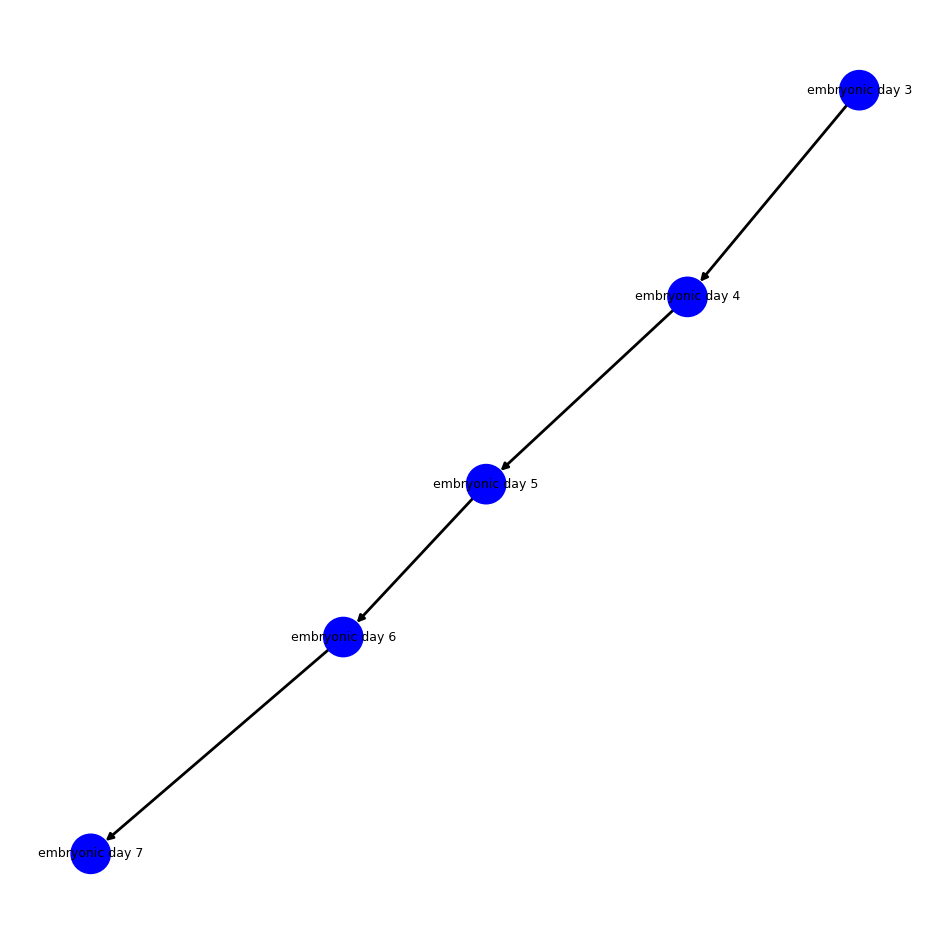

已保存 milestone_network.png
从DI矩阵构建的连接矩阵:
                 Embryonic_day_3  Embryonic_day_4  Embryonic_day_5  \
Embryonic_day_3              0.0              1.0              0.0   
Embryonic_day_4              0.0              0.0              1.0   
Embryonic_day_5              0.0              0.0              0.0   
Embryonic_day_6              0.0              0.0              0.0   
Embryonic_day_7              0.0              0.0              0.0   

                 Embryonic_day_6  Embryonic_day_7  
Embryonic_day_3              0.0              0.0  
Embryonic_day_4              0.0              0.0  
Embryonic_day_5              1.0              0.0  
Embryonic_day_6              0.0              1.0  
Embryonic_day_7              0.0              0.0  
非零连接数: 4


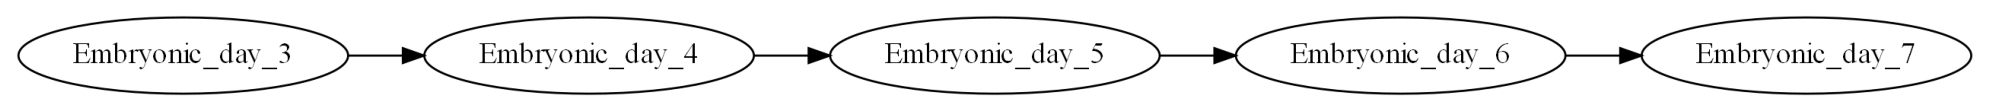

实际聚类顺序: ['Embryonic_day_6', 'Embryonic_day_5', 'Embryonic_day_4', 'Embryonic_day_7', 'Embryonic_day_3']
传入的连接矩阵内容:
                 Embryonic_day_3  Embryonic_day_4  Embryonic_day_5  \
Embryonic_day_3              0.0              1.0              0.0   
Embryonic_day_4              0.0              0.0              1.0   
Embryonic_day_5              0.0              0.0              0.0   
Embryonic_day_6              0.0              0.0              0.0   
Embryonic_day_7              0.0              0.0              0.0   

                 Embryonic_day_6  Embryonic_day_7  
Embryonic_day_3              0.0              0.0  
Embryonic_day_4              0.0              0.0  
Embryonic_day_5              1.0              0.0  
Embryonic_day_6              0.0              1.0  
Embryonic_day_7              0.0              0.0  
非零连接数: 4
图中的边: [('Embryonic_day_3', 'Embryonic_day_4'), ('Embryonic_day_4', 'Embryonic_day_5'), ('Embryonic_day_5', 'Embryonic_day_6'), ('Embryonic_day_

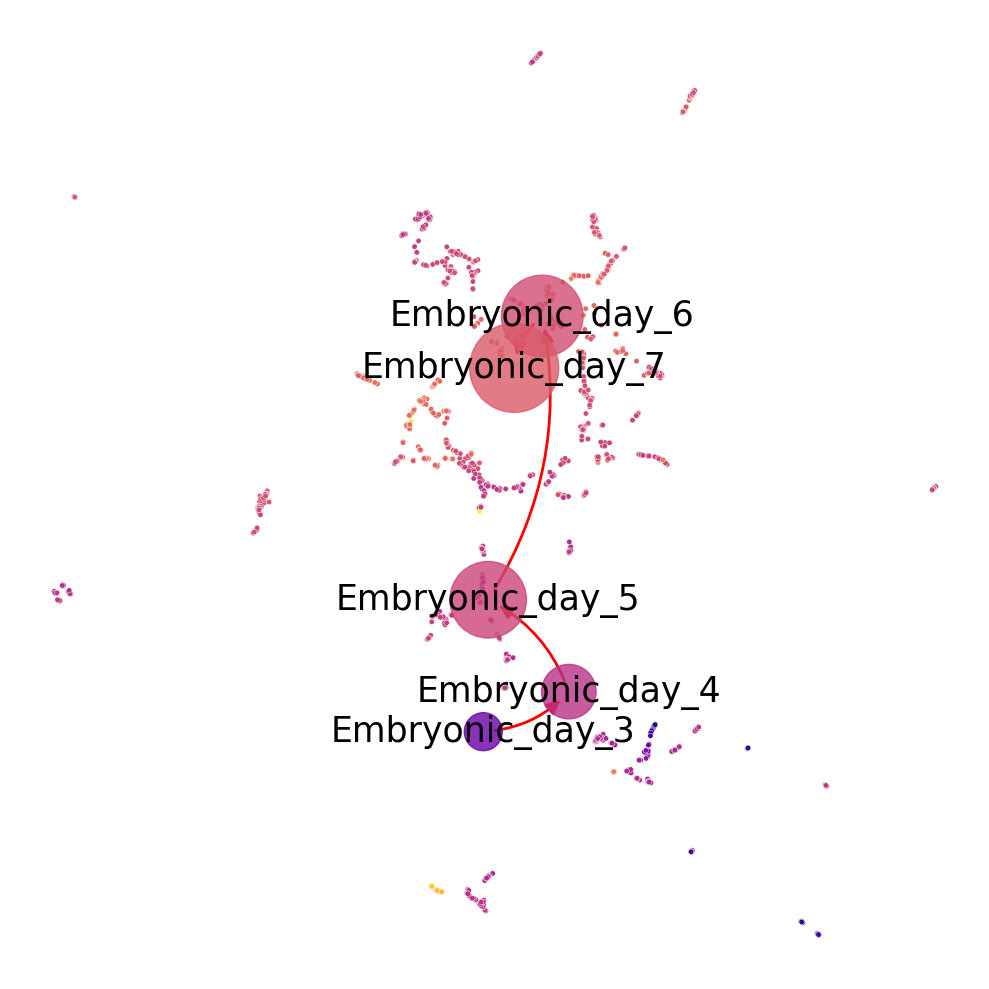

已输出 trajectory tree / pseudotime 图


In [ ]:
print("\n" + "=" * 80)
print("绘制轨迹图")
print("=" * 80)

try:
    plot_gt_milestone_network(adata_hvg)
    plt.savefig(OUTDIR / "milestone_network.png", dpi=300, bbox_inches="tight")
    plt.close()
    print("已保存 milestone_network.png")
except Exception as e:
    print("plot_gt_milestone_network 失败：", e)

adata_hvg.obs["cluster"] = adata_hvg.obs["cascat_clusters"].astype(str)

try:
    obj = DIPlot(
        adata_hvg,
        start_cell_idx=adata_hvg.uns["start_id"],
        root=adata_hvg.uns["root"],
        group_frac=adata_hvg.uns["group_frac"],
        save_path=str(OUTDIR),
        pseudo_key="cascat_pseudotime",
        di_key="cascat_directed_tree_conn",
        predict_key="cluster",         
        emb_key="cascat_embedding"
    )
    obj.plot_trajectory_tree()
    obj.plot_pseudotime()
    print("已输出 trajectory tree / pseudotime 图")
except Exception as e:
    print("DIPlot 失败：", e)